In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)

if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f'figure_{plt._trebl_autosave_counter:04d}'
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2
import speed_plotting_helpers

In [3]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099
...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266


In [4]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import tqdm

# Logistic function
def logistic(t, A, k, t0):
    return A / (1 + np.exp(-k * (t - t0)))

df = activities  # your original dataframe

results = []

for adseq, group in tqdm.tqdm(df.groupby('ADseq')):
    t = group['time'].values
    y = group['activity_norm'].values
    y_err = group['error'].values
    
    # initial guesses
    A_guess = y.max()
    k_guess = 0.1
    t0_guess = t[np.argmin(np.abs(y - A_guess/2))]
    
    try:
        # weighted logistic fit
        popt, pcov = curve_fit(
            logistic, t, y,
            p0=[A_guess, k_guess, t0_guess],
            sigma=y_err,
            absolute_sigma=True,
            maxfev=5000
        )
        
        # fitted parameters
        A_fit, k_fit, t0_fit = popt
        
        # smooth curve only over observed time points
        t_fine = np.linspace(t.min(), t.max(), 1000)
        y_fit = logistic(t_fine, A_fit, k_fit, t0_fit)
        
        # maximum value **within the observed interval**
        max_curve = y_fit.max()
        half_max_curve = max_curve / 2
        
        # time where fitted curve crosses half-max
        t_half_from_curve = t_fine[np.argmin(np.abs(y_fit - half_max_curve))]
        
        # predicted y at measured points
        y_pred = logistic(t, *popt)
        r2 = r2_score(y, y_pred)
        
        # parameter uncertainties
        perr = np.sqrt(np.diag(pcov))
        
        results.append({
            'ADseq': adseq,
            'R2': r2,
            'observed_strength': max_curve,      # max curve value in observed interval
            't_half': t_half_from_curve,         # half-max time
            'speed': k_fit,
            'A_err': perr[0],
            'k_err': perr[1],
            't0_err': perr[2]
        })
        
    except RuntimeError:
        results.append({
            'ADseq': adseq,
            'R2': np.nan,
            'observed_strength': np.nan,
            't_half': np.nan,
            'speed': np.nan,
            'A_err': np.nan,
            'k_err': np.nan,
            't0_err': np.nan
        })

results_df = pd.DataFrame(results)
print(results_df.head())

100%|██████████| 857/857 [00:01<00:00, 833.04it/s]

                                      ADseq        R2  observed_strength  \
0  AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN  0.899217           1.137649   
1  AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY  0.985163           1.513870   
2  AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS  0.965885           1.370633   
3  AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS  0.969545           0.921619   
4  AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF  0.977986           1.347826   

     t_half     speed     A_err         k_err       t0_err  
0  2.042042  8.315258  0.032651  1.071919e+06  5422.149458  
1  6.606607  0.347899  0.028456  5.117243e-02     0.514564  
2  7.267267  0.264424  0.016834  3.378992e-02     0.594651  
3  8.828829  0.342122  0.042433  1.050402e-01     1.059940  
4  7.387387  0.469859  0.052820  1.299018e-01     0.884563  


In [5]:
results_df

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.899217,1.137649,2.042042,8.315258,0.032651,1.071919e+06,5422.149458
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,0.985163,1.513870,6.606607,0.347899,0.028456,5.117243e-02,0.514564
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,0.965885,1.370633,7.267267,0.264424,0.016834,3.378992e-02,0.594651
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,0.969545,0.921619,8.828829,0.342122,0.042433,1.050402e-01,1.059940
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,0.977986,1.347826,7.387387,0.469859,0.052820,1.299018e-01,0.884563
...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,0.969998,1.390677,9.549550,0.264269,0.020160,3.621651e-02,0.586004
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,0.980868,0.942420,10.930931,0.265730,0.038438,6.958142e-02,1.211087
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,0.980009,1.436320,8.288288,0.277785,0.029162,4.411391e-02,0.696579
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,0.981563,1.107947,10.210210,0.248216,0.021477,4.608696e-02,0.764332


In [6]:
ok = results_df[results_df["R2"] >= 0.7]
print(f"Keeping {len(ok)} / {len(results_df)} sequences ({100*len(ok)/len(results_df):.1f}%)")

Keeping 855 / 857 sequences (99.8%)


In [7]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/logistic_fit_baseline_norm.csv")

In [8]:
not_ok = results_df[results_df["R2"] < 0.7]
not_ok

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
170,ENEQDSLALDDLDRAFELVEGMDMDWMMPSHAHHSPATTA,0.633157,1.604988,5.705706,0.712834,0.042863,0.115287,0.209745
314,ILNEYNMNFNDNLGTSTSGKNKSACPSSFDANAMTKINPS,0.236666,0.838363,14.774775,0.059286,0.366674,0.055484,19.293550


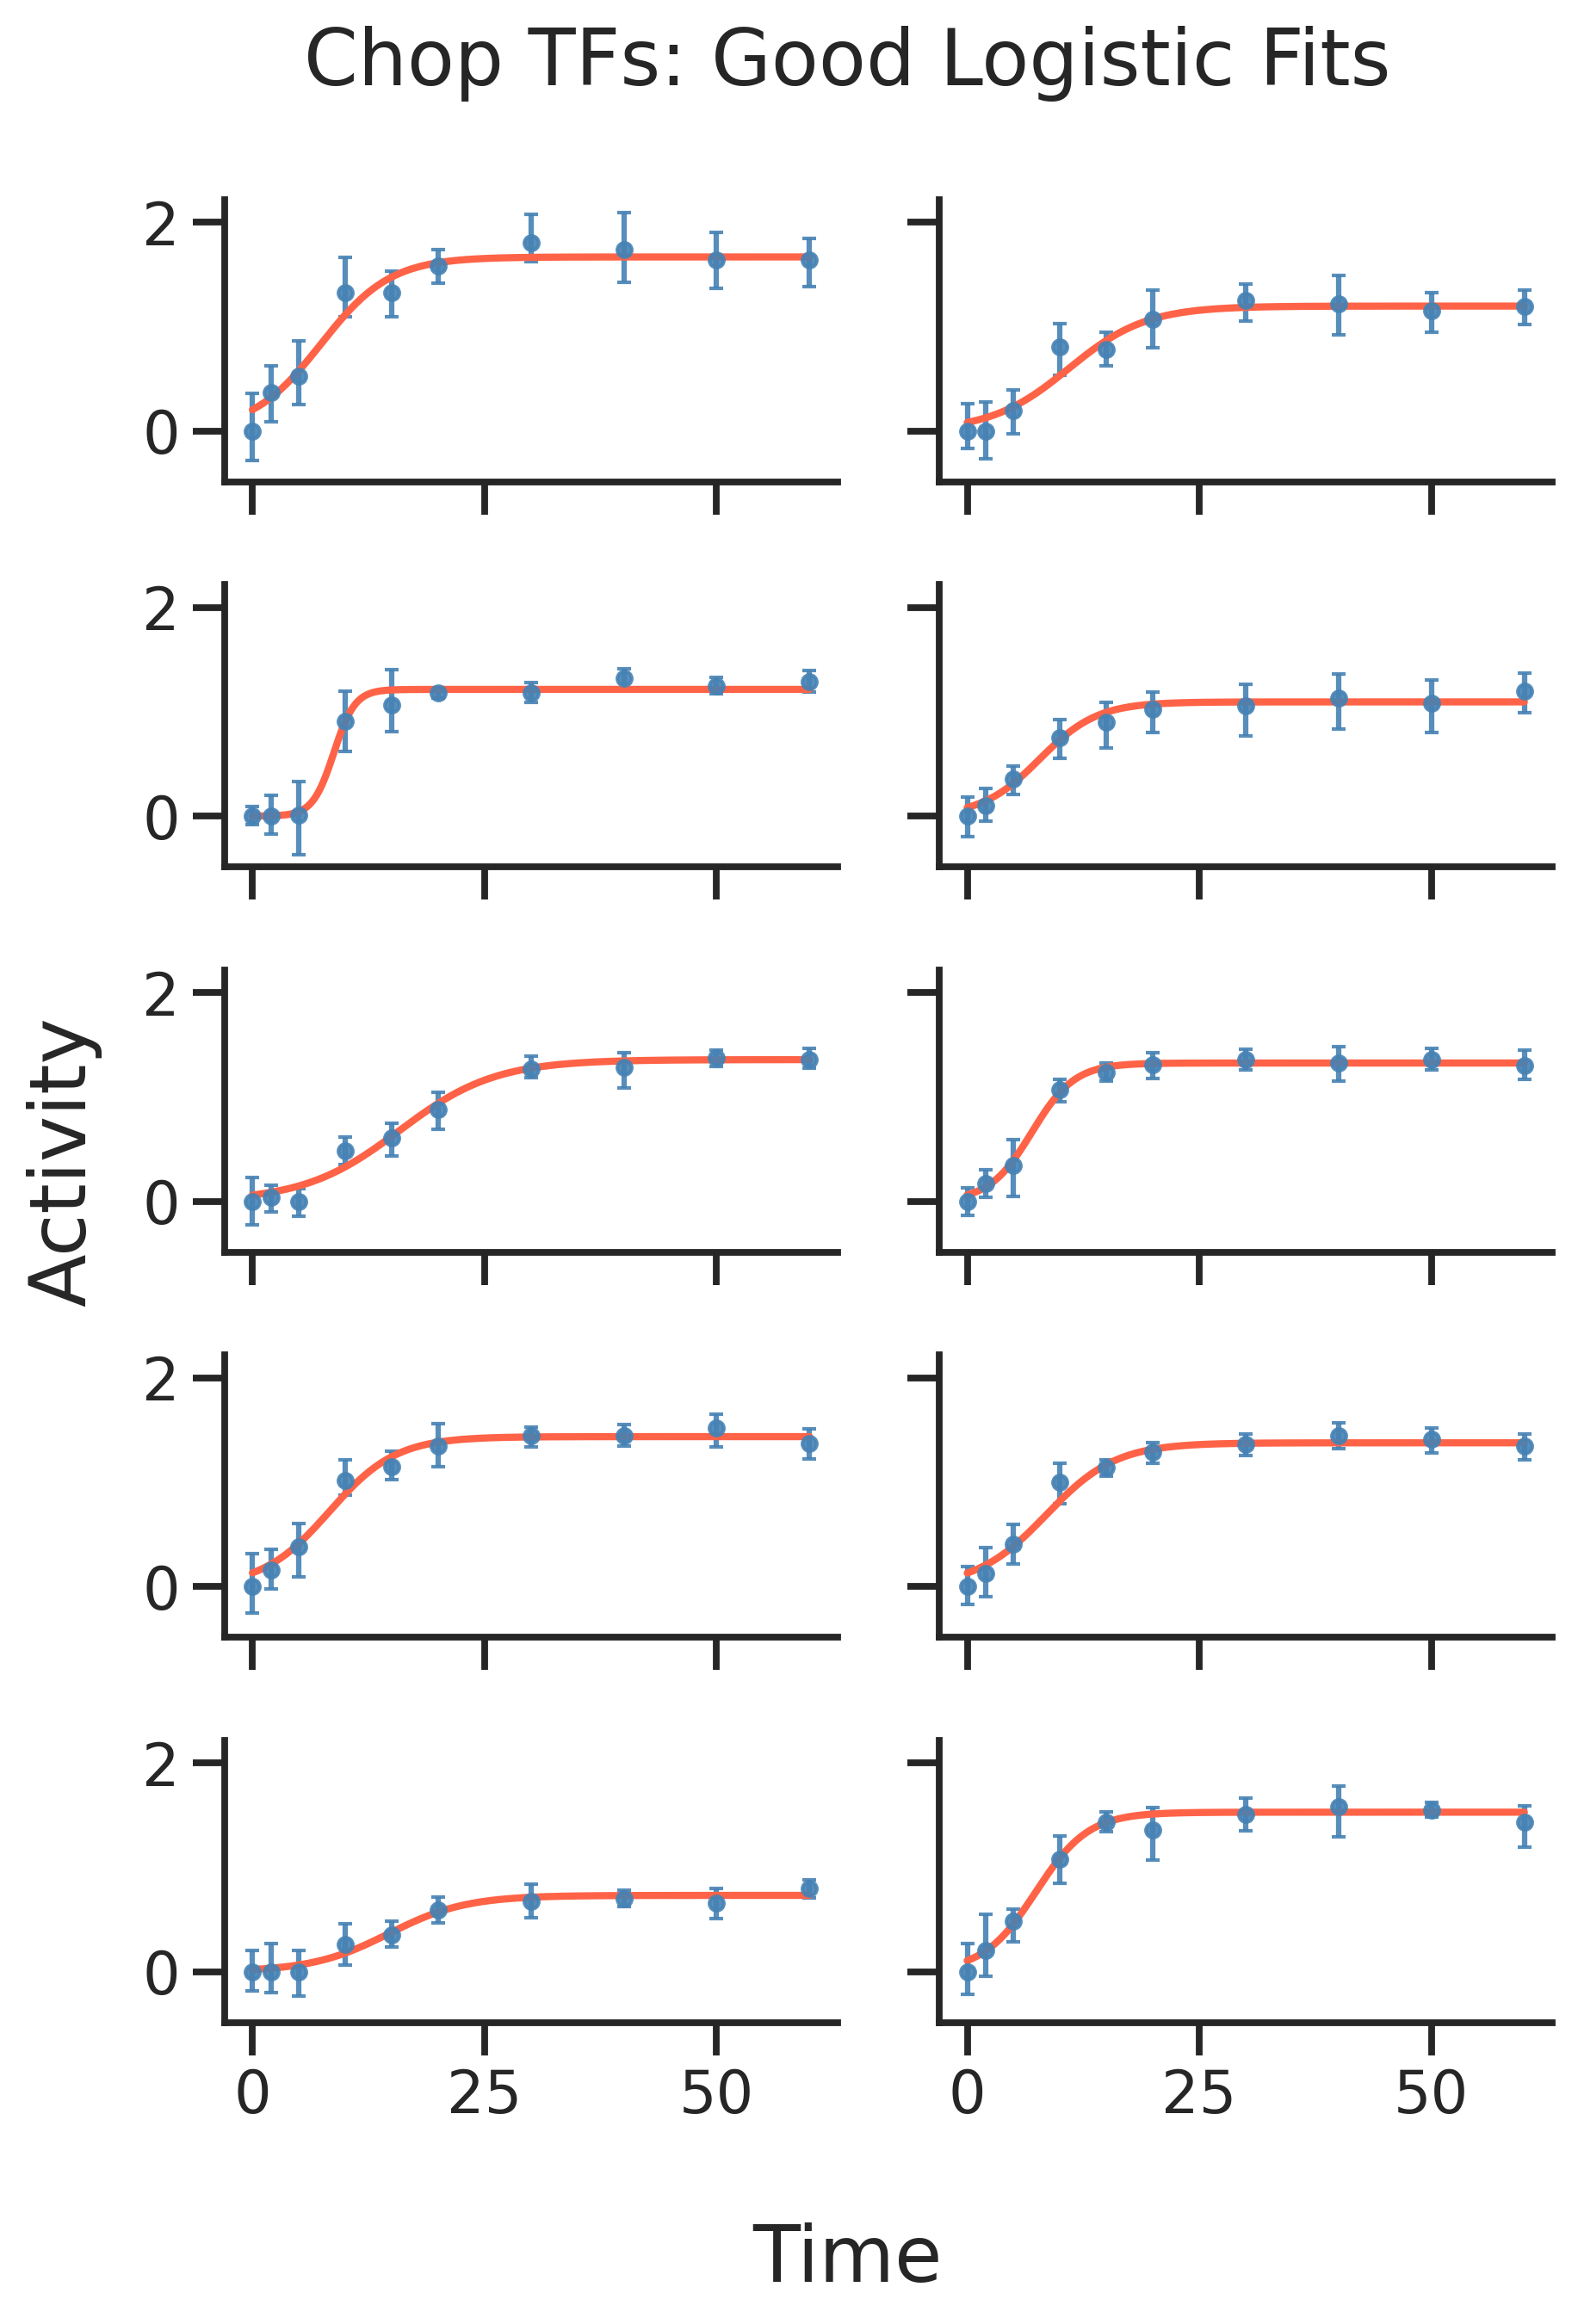

ValueError: Cannot take a larger sample than population when 'replace=False'

In [10]:
for df, title in zip([ok, not_ok], ["Good", "Bad"]):
    sample_adseqs = df.sample(16, random_state=44)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities,
        fit_results=results_df,
        sample_adseqs=sample_adseqs,
        model_fn=logistic,
        model_params=['observed_strength', 'speed', 't_half'],
        y_col='activity_norm',
        ci_low_col="ci_low_norm",
        ci_hi_col="ci_hi_norm",
        title=f'Chop TFs: {title} Logistic Fits',
    )

Pearson r = -0.567, p = 8.78e-74
Spearman rho = -0.612, p = 5.49e-89


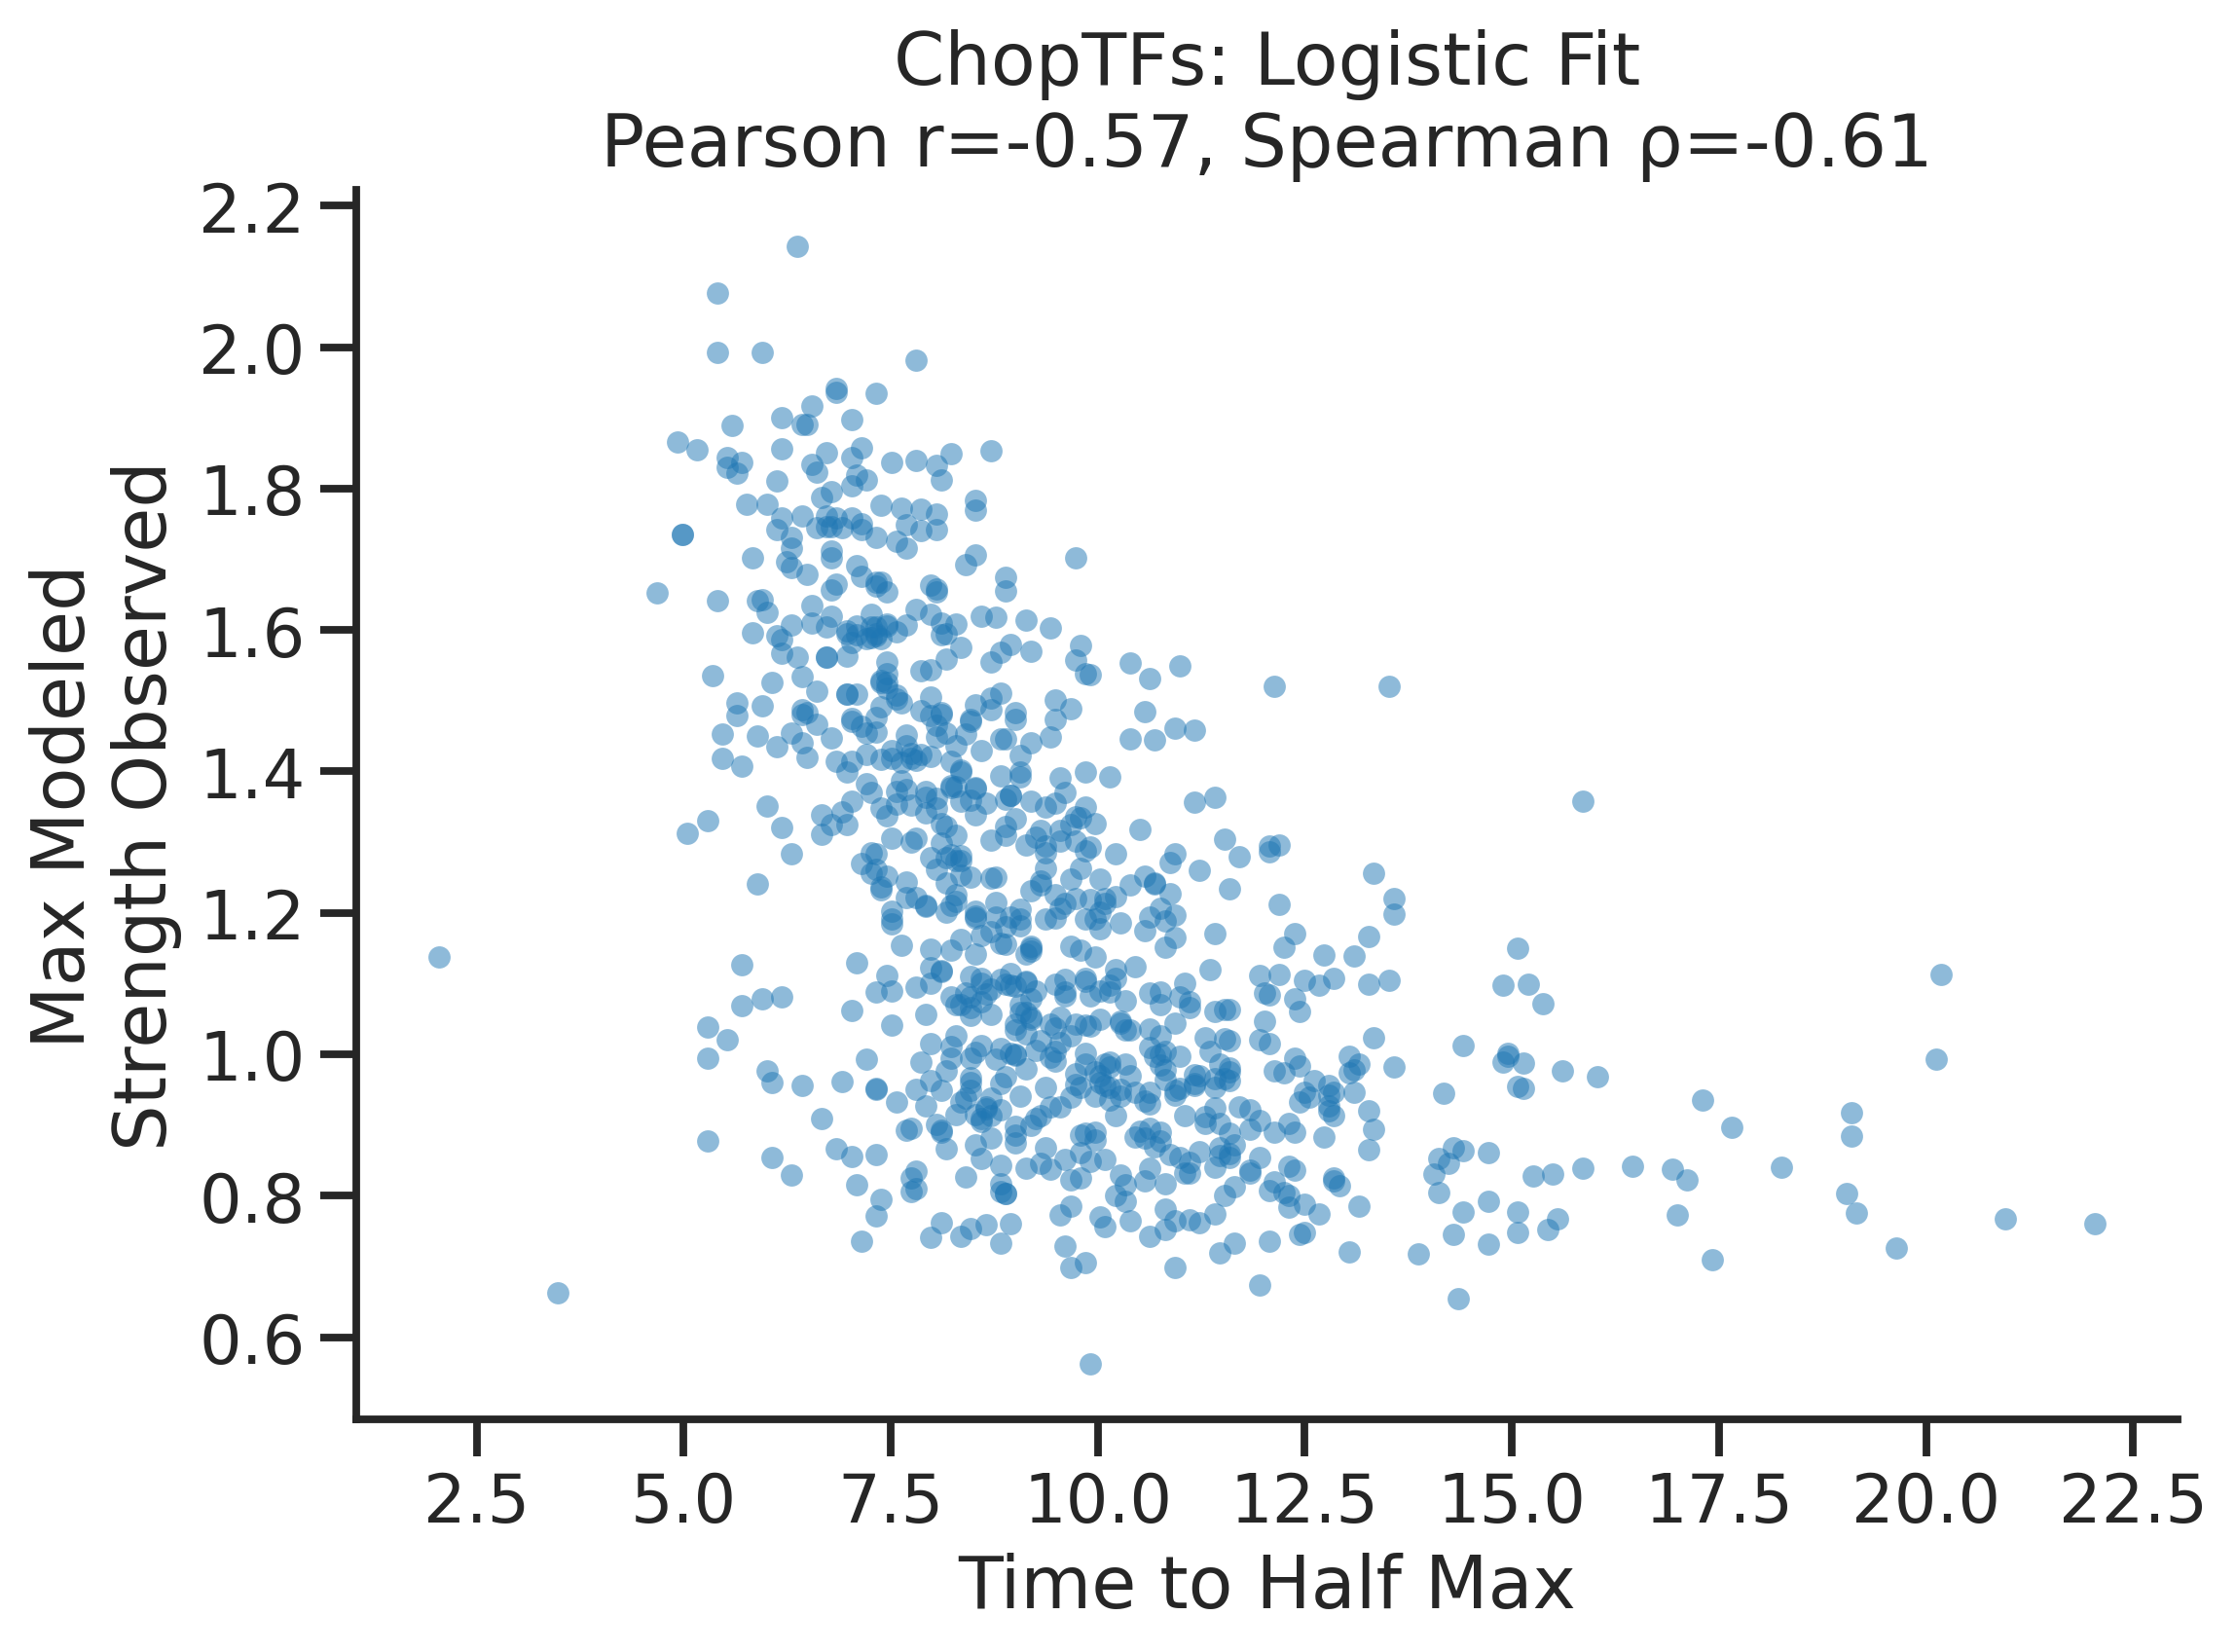

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half'], ok ['observed_strength'])
spearman_corr, spearman_p = spearmanr(ok['t_half'], ok ['observed_strength'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half'], ok['observed_strength'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Logistic Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

In [12]:
# --- filter valid sequences ---
filtered = results_df[
    (ok['speed'] >= 0) &
    (results_df['observed_strength'] >= 0) 
].copy()

# --- 1. Similar strength (A), different speed (k) ---
A_target = filtered['observed_strength'].median()
A_tol = filtered['observed_strength'].std() * 0.3

similar_A = filtered[(filtered['observed_strength'] >= A_target - A_tol) &
                     (filtered['observed_strength'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('speed')

if len(similar_A_sorted) >= 2:
    seq_simA_diffk = similar_A_sorted.iloc[[0,-1]]  # pick lowest and highest speed
else:
    seq_simA_diffk = similar_A_sorted.copy()  # fallback if not enough sequences

# --- 2. Similar speed (k), different strength (A) ---
k_target = filtered['speed'].median()
k_tol = filtered['speed'].std() * 0.3

similar_k = filtered[(filtered['speed'] >= k_target - k_tol) &
                     (filtered['speed'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('observed_strength')

if len(similar_k_sorted) >= 2:
    seq_simk_diffA = similar_k_sorted.iloc[[0, -1]]  # pick lowest and highest strength
else:
    seq_simk_diffA = similar_k_sorted.copy()  # fallback

# --- combine sequences to plot ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA]).reset_index(drop=True)
to_plot

,ADseq,R2,observed_strength,t_half,speed,A_err,k_err,t0_err
0,DFYQIKDRVLVKEVYNPEDLYHLRILNSLTACYLEYSISY,0.983108,1.113079,20.180180,0.155745,0.080621,3.304813e-02,2.004560
1,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.899217,1.137649,2.042042,8.315258,0.032651,1.071919e+06,5422.149458
2,EITKFGIENGIVKVIPPKEWLELLEGSPPAESLKTIQLDS,0.946726,0.698089,10.930931,0.212260,0.035853,5.562782e-02,1.320886
3,SPTNVGTLHENLSSSHFMIPDVDQFNSFEDFFQDFFDSLK,0.963107,2.142937,6.366366,0.294526,0.031349,3.556186e-02,0.484109


Pearson r = -0.567, p = 8.78e-74
Spearman rho = -0.612, p = 5.49e-89


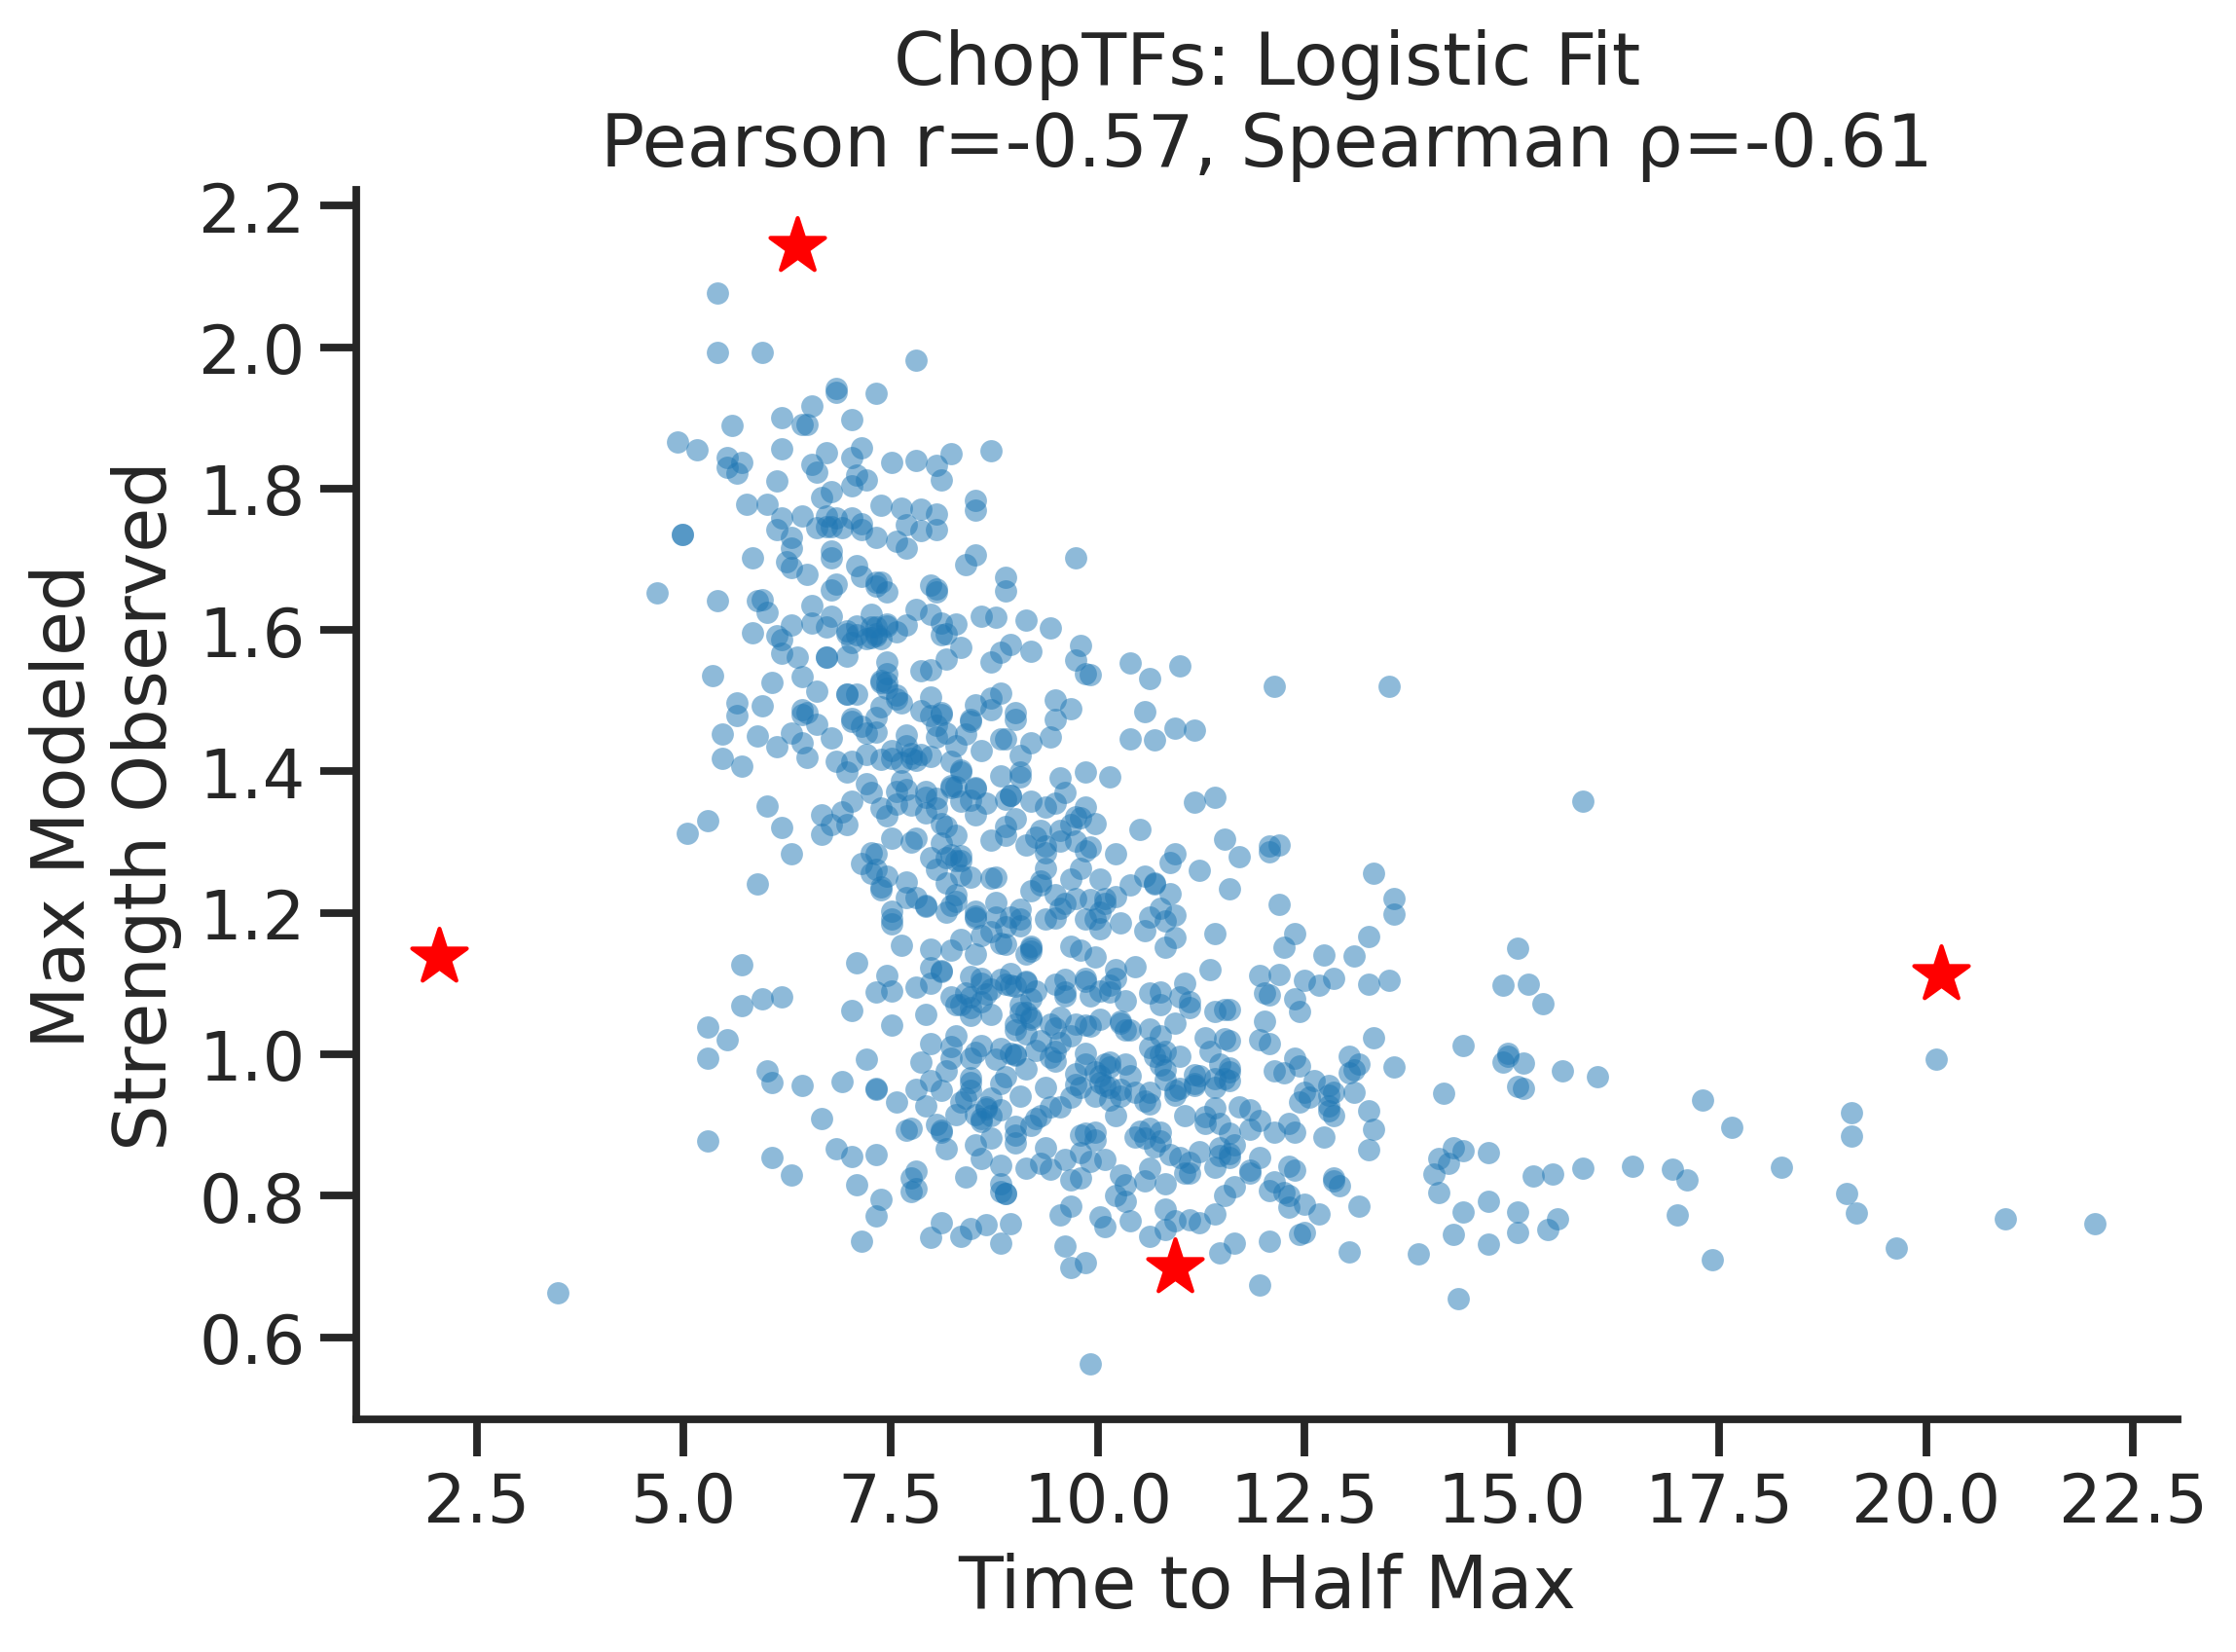

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half'], ok ['observed_strength'])
spearman_corr, spearman_p = spearmanr(ok['t_half'], ok ['observed_strength'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half'], ok['observed_strength'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['t_half'], to_plot['observed_strength'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)

ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Logistic Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

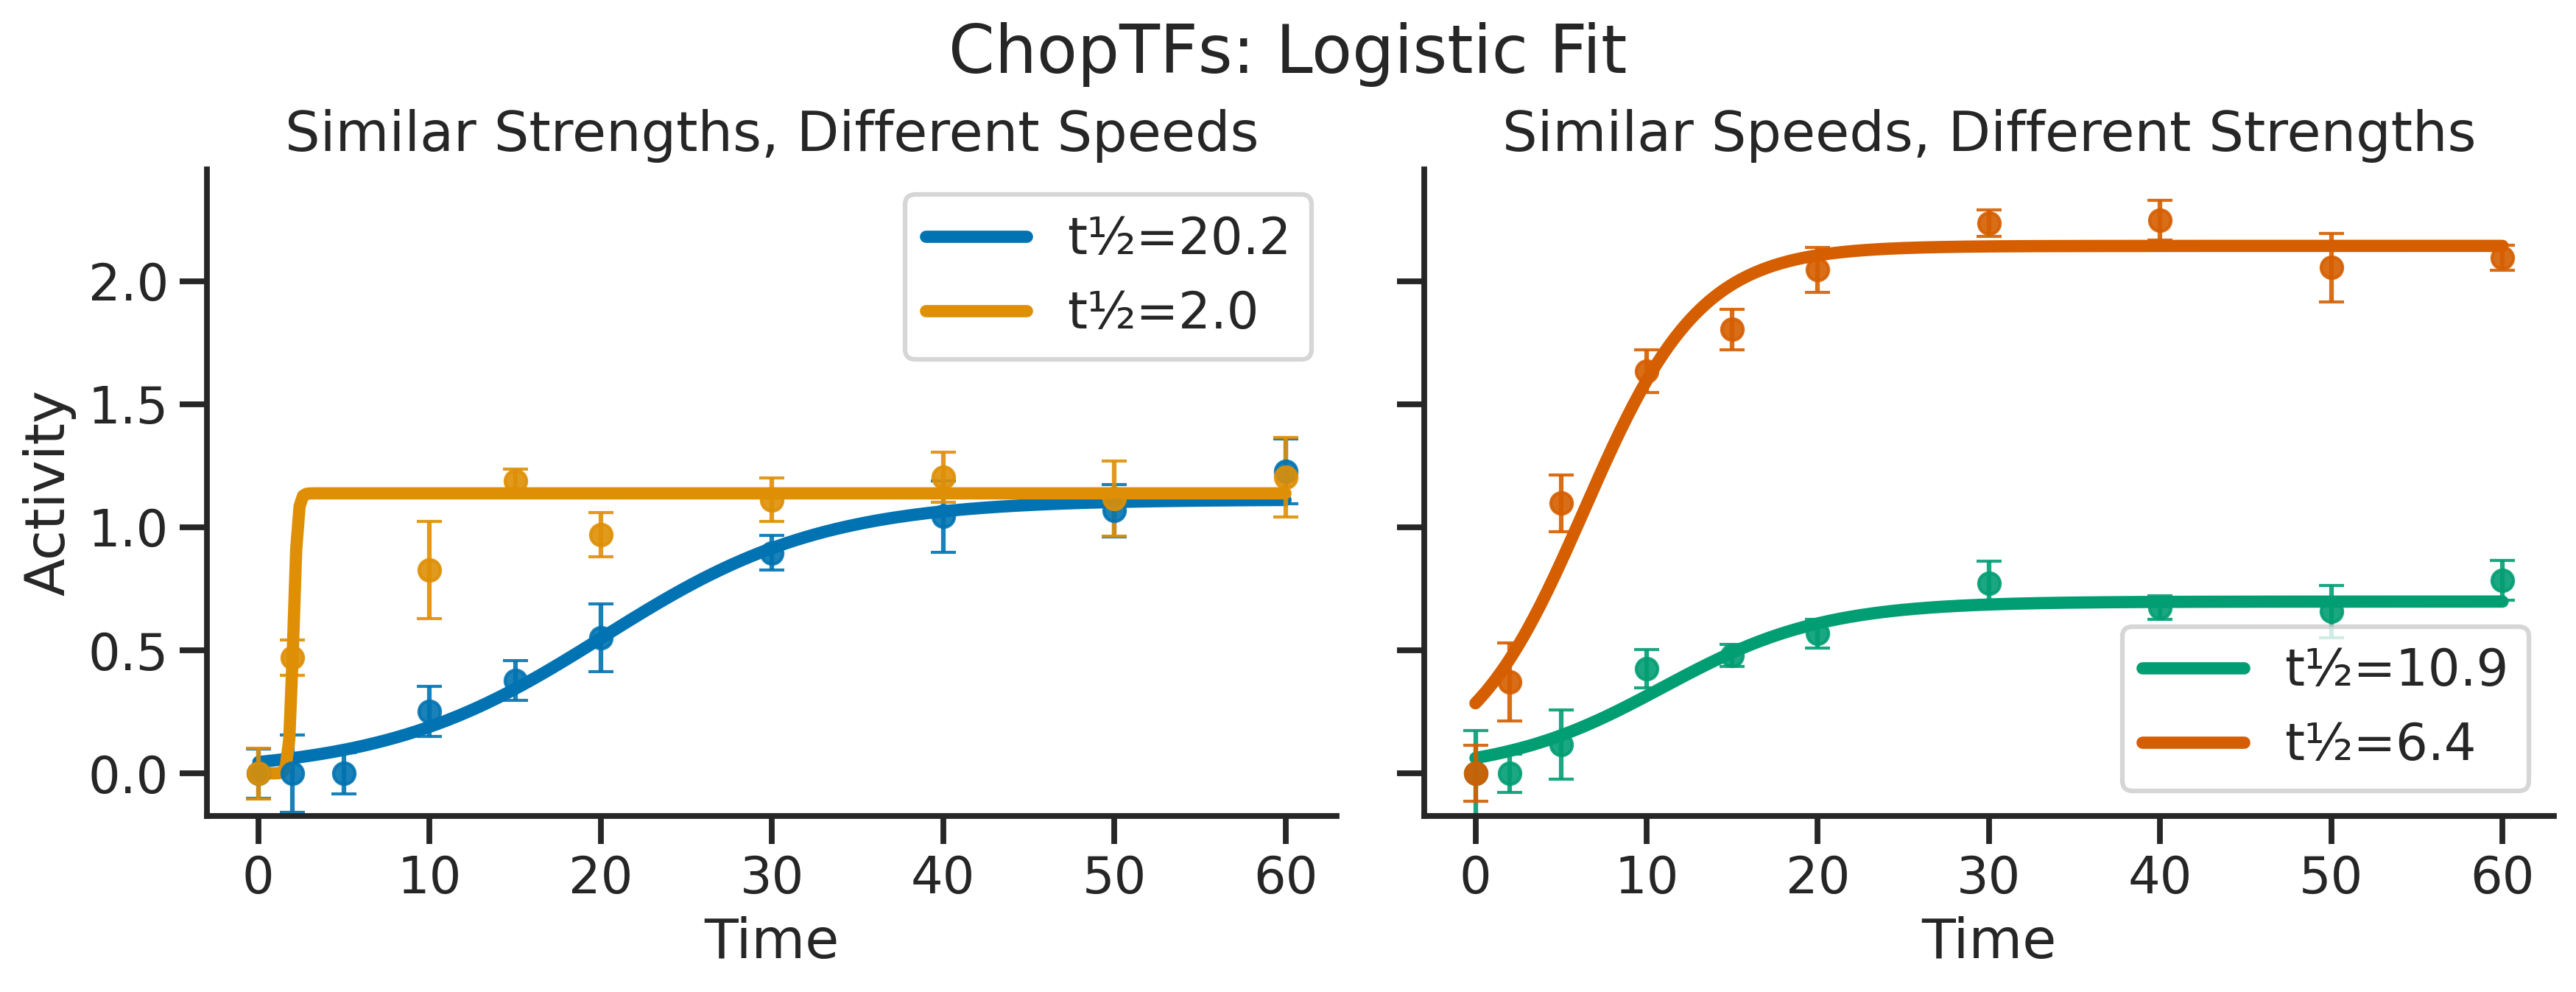

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')

# --- logistic function ---
def logistic(t, A, k, t_half):
    return A / (1 + np.exp(-k * (t - t_half)))

t_fine = np.linspace(0, activities['time'].max(), 300)
colors = sns.color_palette('colorblind', n_colors=4)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

# -----------------------------
# Similar Strength, Different Speeds
# -----------------------------
for idx in [0, 1]:

    row = to_plot.iloc[idx]
    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[0].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=4,
        markersize=7,
        alpha=0.9
    )

    axs[0].plot(
        t_fine,
        logistic(t_fine, row['observed_strength'], row['speed'], row['t_half']),
        color=colors[idx],
        linewidth=4,
        label=f"t½={row['t_half']:.1f}"
    )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].set_title("Similar Strengths, Different Speeds")
axs[0].legend()
sns.despine(ax=axs[0])

# -----------------------------
# Similar Speed, Different Strengths
# -----------------------------
for idx in [2, 3]:

    row = to_plot.iloc[idx]
    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[1].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=4,
        markersize=7,
        alpha=0.9
    )

    axs[1].plot(
        t_fine,
        logistic(t_fine, row['observed_strength'], row['speed'], row['t_half']),
        color=colors[idx],
        linewidth=4,
        label=f"t½={row['t_half']:.1f}"
    )

axs[1].set_xlabel('Time')
axs[1].set_title("Similar Speeds, Different Strengths")
axs[1].legend()
sns.despine(ax=axs[1])

# -----------------------------
# shared y-axis scaling
# -----------------------------
grps = activities[activities['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

plt.suptitle("ChopTFs: Logistic Fit", y=0.912)
plt.tight_layout()
plt.show()